# Method 1 V2 — post-training diagnostics

Compare **baseline** `edge_weight`, **teacher-only** `edge_teacher_agreement` (no ML), and **V2** `edge_plausibility`.

**GT labels** are used only inside Step 3 metric evaluation (`v_measure`, homogeneity, completeness), consistent with existing notebooks.

## Sections
1. Paths and imports  
2. Load Step 2 + build / load teacher scored edges  
3. Score distributions  
4. Correlations, scatter / hexbin, top-k overlap  
5. Step 3 sweeps (baseline vs teacher vs V2)  
6. Fair comparison + top rows  
7. Matched edge-count comparison  
8. Per-epoch checkpoints (requires `save_every_epoch_checkpoint=True` in training)  
8b. Same vs cross & HS-LI score evolution (distributions per checkpoint)  
9. Interesting-edge buckets  
9b. V2 ranking supervision (bucket / teacher-fallback stats)  
10. Training history (losses, stds, optional GT diag gaps) + final-run separation artifacts  
11. Export tables / optional markdown report  


## 1. Paths and imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_here = Path.cwd().resolve()
PROJECT_ROOT = _here if (_here / "pipeline_config.json").is_file() else _here.parent
assert (PROJECT_ROOT / "pipeline_config.json").is_file(), f"Set cwd to repo root or analysis/; got {PROJECT_ROOT}"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis.utils import semantic_shard_graph_helpers as s2
from analysis.utils import semantic_shard_step3_helpers as s3
from analysis.utils.semantic_shard_edge_teacher_score import (
    TEACHER_WEIGHT_COL,
    build_teacher_scored_edges,
    save_teacher_bundle,
)
from analysis.utils.semantic_shard_method2_v2_diagnostics import (
    add_rank_columns,
    disagreement_edge_buckets,
    evaluate_v2_checkpoint_epochs,
    evaluate_v2_checkpoint_same_cross_score_stats,
    fair_method_comparison_table,
    fraction_above_thresholds_table,
    load_gt_label_map,
    load_v2_ranking_supervision_meta,
    load_v2_training_history,
    matched_edge_count_table,
    merge_edge_score_frame,
    pairwise_correlation_table,
    run_step3_sweep_df,
    score_column_summary,
    summaries_to_table,
    sweep_long_for_plotting,
    top_n_sweep_results,
    topk_overlap_scores,
    save_disagreement_bucket_csvs,
    save_v2_ranking_supervision_diagnostics_report,
    v2_bucket_counts_table_from_meta,
    v2_positive_subpath_counts_table_from_meta,
    v2_ranking_supervision_fallback_per_epoch_df,
    v2_ranking_supervision_fallback_run_summary,
    v2_ranking_supervision_factual_note,
    score_v2_at_epoch_checkpoint,
    v2_gt_same_cross_hsli_masks,
)
from analysis.utils.semantic_shard_method2_v2_diagnostics_plots import (
    plot_epoch_curves,
    plot_metrics_vs_n_edges,
    plot_same_cross_histogram_snapshots,
    plot_same_cross_score_evolution,
    plot_score_cdf,
    plot_score_histograms,
    plot_scatter_scores,
    plot_separation_gaps_vs_epoch,
    plot_sweep_heatmap,
    plot_topk_overlap_bars,
    plot_training_history_losses,
    plot_training_history_multipanel,
    write_diagnostics_report_md,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)


In [2]:
# -------- User controls --------
# Step 2 graph directory (from Step 2 build — NOT the V2 run folder).
# Must contain semantic_shard_step2_nodes.csv (often this path has no extra subfolder).
STEP2_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step2_graph"
# If you built the routing-inclusive graph instead, use:
# STEP2_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step2_graph_routing"

STEP1_ASSIGNMENTS_CSV = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step1" / "semantic_shard_step1_assignments.csv"
GT_JSON = PROJECT_ROOT / "data" / "groundtruth" / "ground_truth.json"

# V2 plausibility run (from train_and_score — different path than Step 2).
# Contains method2_config.json, feature_manifest.json, semantic_shard_step2_edges_scored.csv, model.pt, …
V2_RUN_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_edge_v2" / "run_contrastive_new_regularizer"

# Where to write teacher-only bundle (Step 3 weight_col=edge_teacher_agreement)
TEACHER_RUN_ID = "teacher_step2_graph"
TEACHER_OUTPUT_ROOT = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_edge_teacher"

# Optional: directory for exported diagnostic CSVs / figures
DIAG_OUT = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_method2_diagnostics" / "run_contrastive_new_regularizer"
DIAG_OUT.mkdir(parents=True, exist_ok=True)

# Step 3 sweep grid (shrink for quick iteration)
COMMUNITY_METHOD = "louvain"
RESOLUTION_VALUES = [1.5, 2.0, 2.5, 3, 3.5, 4]
MIN_EDGE_WEIGHT_VALUES = [0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.2, 0.3]
STEP3_SEED = 0

# Per-epoch eval: only these checkpoint epochs (1-based), or None for all under checkpoints/
EPOCH_CHECKPOINT_FILTER = None  # e.g. {1, 2, 3, 5, 10, 15, 20}


## 2. Load Step 2, V2 scored edges, teacher bundle

In [3]:
_s2_nodes = Path(STEP2_DIR) / "semantic_shard_step2_nodes.csv"
if not _s2_nodes.is_file():
    raise FileNotFoundError(
        f"Missing {_s2_nodes}\n"
        "STEP2_DIR must be the Step 2 graph folder "
        "(.../semantic_shard_step2_graph/<step2_run_id>/), "
        "not the V2 folder (.../semantic_shard_edge_v2/<v2_run_id>/)."
    )

nodes_df, edges_df, _cand = s3.load_step2_artifacts(STEP2_DIR)
assignments_df = s2.load_step1_assignments(STEP1_ASSIGNMENTS_CSV)
shard_ids = nodes_df["shard_id"].astype(str).tolist()
gt_label_map = load_gt_label_map(GT_JSON)

v2_edges_path = V2_RUN_DIR / "semantic_shard_step2_edges_scored.csv"
v2_scored = pd.read_csv(v2_edges_path)
v2_scored["shard_a"] = v2_scored["shard_a"].astype(str)
v2_scored["shard_b"] = v2_scored["shard_b"].astype(str)

# Build and save teacher-only scored edges (same row order as Step 2 edges)
teacher_paths = save_teacher_bundle(
    edges_df,
    run_id=TEACHER_RUN_ID,
    output_root=TEACHER_OUTPUT_ROOT,
    extra_meta={"step2_dir": str(STEP2_DIR)},
)
teacher_scored = pd.read_csv(teacher_paths["scored_edges_csv"])
teacher_scored["shard_a"] = teacher_scored["shard_a"].astype(str)
teacher_scored["shard_b"] = teacher_scored["shard_b"].astype(str)
print("Teacher bundle:", teacher_paths["output_dir"])

merged = merge_edge_score_frame(
    edges_df,
    teacher_scored=teacher_scored,
    v2_scored=v2_scored,
)
merged.head(3)

Teacher bundle: C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\semantic_shard_edge_teacher\teacher_step2_graph


,shard_a,shard_b,centroid_cosine,shared_url_count,url_jaccard,shared_url_idf_sum,shared_url_n_cutoff_filtered,infra_contrib_url_pre_cap,infra_contrib_url,shared_sender_email_domain_count,sender_email_domain_jaccard,shared_sender_email_domain_idf_sum,shared_sender_email_domain_n_cutoff_filtered,infra_contrib_sender_email_domain_pre_cap,infra_contrib_sender_email_domain,shared_domain_count,domain_jaccard,shared_domain_idf_sum,shared_domain_n_cutoff_filtered,infra_contrib_domain_pre_cap,infra_contrib_domain,shared_stem_count,stem_jaccard,shared_stem_idf_sum,shared_stem_n_cutoff_filtered,infra_contrib_stem_pre_cap,infra_contrib_stem,shared_sender_count,sender_jaccard,shared_sender_idf_sum,shared_sender_n_cutoff_filtered,infra_contrib_sender_pre_cap,infra_contrib_sender,infra_score,temporal_overlap,temporal_gap_days,temporal_score,edge_weight,view_semantic,view_infra,view_temporal,edge_teacher_agreement,edge_plausibility
0,shard_307,shard_394,0.879659,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,1,1.000000,6.120386,0,0.598681,0.598681,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0.598681,1.0,0.0,1.0,0.765253,0.933490,0.515784,0.000000,0.007838,0.151867
1,shard_307,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBl...,0.839818,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,1,0.166667,6.120386,0,0.598681,0.598681,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0.598681,1.0,0.0,1.0,0.747325,0.640231,0.515914,0.000025,0.020224,0.056992
2,shard_307,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMy...,0.872631,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,1,1.000000,6.120386,0,0.598681,0.598681,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0.598681,1.0,0.0,1.0,0.762091,0.911329,0.385879,0.000050,0.026018,0.150209


## 3. Score distributions

,score_source,n,min,max,mean,std,median,frac_mid_04_06,frac_lt_01,frac_gt_09,n_unique_approx,q_01,q_05,q_10,q_25,q_50,q_75,q_90,q_95,q_99
0,baseline_edge_weight,39935,5.276489e-01,2.124851,0.998316,0.336686,0.738834,0.004007,0.000000,0.404207,37401,0.702077,0.711556,0.715971,0.724126,0.738834,1.404900,1.419621,1.427854,1.453220
1,teacher_agreement,39935,4.724578e-03,0.997520,0.430682,0.182964,0.426283,0.385051,0.021936,0.004758,39935,0.070444,0.141387,0.187262,0.296424,0.426283,0.552361,0.673696,0.754309,0.867578
2,v2_plausibility,39935,5.657793e-07,0.995416,0.183723,0.253219,0.070726,0.059371,0.571979,0.017704,39890,0.000100,0.000768,0.002243,0.013161,0.070726,0.210677,0.650303,0.810614,0.927881


,score_source,frac_ge_0.50,frac_ge_0.60,frac_ge_0.70,frac_ge_0.80,frac_ge_0.90
0,baseline_edge_weight,1.000000,0.995993,0.992338,0.409140,0.404207
1,teacher_agreement,0.351621,0.171704,0.077626,0.029974,0.004758
2,v2_plausibility,0.141004,0.113760,0.083961,0.053337,0.017704


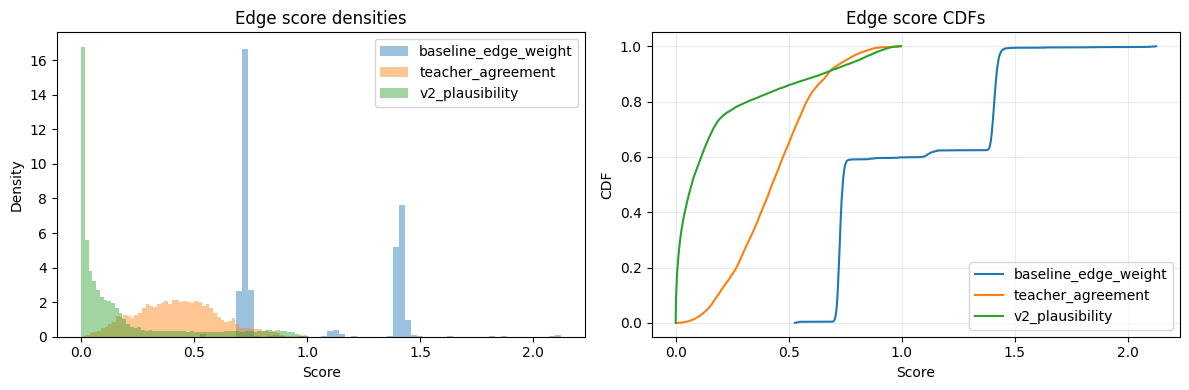

In [4]:
score_cols = {
    "baseline_edge_weight": merged["edge_weight"],
    "teacher_agreement": merged[TEACHER_WEIGHT_COL],
    "v2_plausibility": merged["edge_plausibility"],
}
summaries = {k: score_column_summary(v, k) for k, v in score_cols.items()}
display(summaries_to_table(summaries))
display(fraction_above_thresholds_table(score_cols))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_score_histograms({k: v.values for k, v in score_cols.items()}, title="Edge score densities", ax=axes[0])
plot_score_cdf({k: v.values for k, v in score_cols.items()}, title="Edge score CDFs", ax=axes[1])
plt.tight_layout()
plt.show()

## 4. Correlations, scatter / hexbin, top-k overlap

,col_a,col_b,pearson,spearman,n_pairwise
0,edge_weight,edge_teacher_agreement,0.443183,0.565516,40004
1,edge_weight,edge_plausibility,0.617441,0.756531,40004
2,edge_teacher_agreement,edge_plausibility,0.589418,0.655638,40004


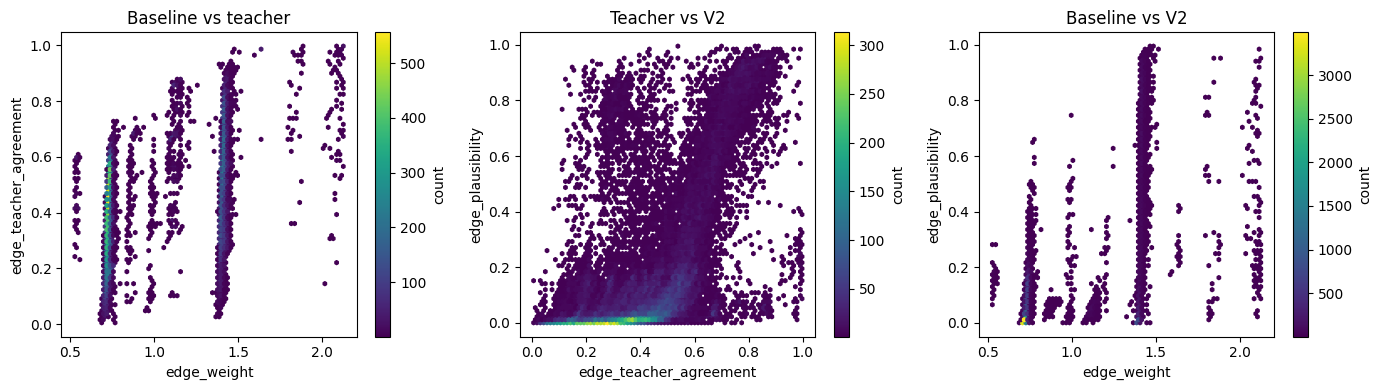

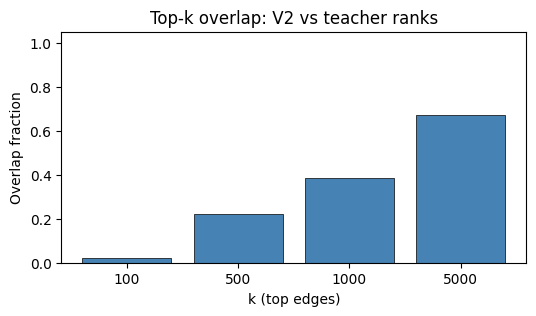

In [5]:
corr_tbl = pairwise_correlation_table(
    merged, ["edge_weight", TEACHER_WEIGHT_COL, "edge_plausibility"]
)
display(corr_tbl)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_scatter_scores(
    merged["edge_weight"],
    merged[TEACHER_WEIGHT_COL],
    xlab="edge_weight",
    ylab=TEACHER_WEIGHT_COL,
    title="Baseline vs teacher",
    hexbin=True,
    ax=axes[0],
)
plot_scatter_scores(
    merged[TEACHER_WEIGHT_COL],
    merged["edge_plausibility"],
    xlab=TEACHER_WEIGHT_COL,
    ylab="edge_plausibility",
    title="Teacher vs V2",
    hexbin=True,
    ax=axes[1],
)
plot_scatter_scores(
    merged["edge_weight"],
    merged["edge_plausibility"],
    xlab="edge_weight",
    ylab="edge_plausibility",
    title="Baseline vs V2",
    hexbin=True,
    ax=axes[2],
)
plt.tight_layout()
plt.show()

k_tbl = topk_overlap_scores(
    merged["edge_plausibility"].to_numpy(),
    merged[TEACHER_WEIGHT_COL].to_numpy(),
    ks=[100, 500, 1000, 5000],
)
fig, ax = plt.subplots(figsize=(6, 3))
plot_topk_overlap_bars(k_tbl, title="Top-k overlap: V2 vs teacher ranks", ax=ax)
plt.show()

## 5–7. Step 3 sweeps, fair summary, matched edge counts

Uses the same `run_community_sweep` machinery as Step 3; this cell can be slow on large grids.

,method,best_v_measure,best_homogeneity_at_best_v,best_completeness_at_best_v,min_edge_weight_at_best_v,resolution_at_best_v,n_edges_at_best_v,best_homogeneity_subject_completeness_ge_baseline_best,completeness_at_that_row,best_completeness_subject_homogeneity_ge_baseline_best,homogeneity_at_that_row
0,baseline_edge_weight,0.917074,0.960717,0.877225,0.01,4.0,40004.0,0.960717,0.877225,0.877225,0.960717
1,teacher_agreement,0.916175,0.958547,0.877391,0.08,3.0,39442.0,0.958547,0.877391,0.871351,0.960746
2,v2_plausibility,0.916346,0.951969,0.883293,0.01,2.5,31114.0,0.951969,0.883293,0.737771,0.978774


'baseline'

,setting_key,method_requested,method_used,weight_col,resolution,min_edge_weight,n_edges_after_threshold,n_communities,n_eval,coverage_gt,homogeneity,completeness,v_measure
0,w0.010_r4.000,louvain,louvain,edge_weight,4.0,0.01,40004.0,1050.0,1472.0,1.0,0.960717,0.877225,0.917074
1,w0.020_r4.000,louvain,louvain,edge_weight,4.0,0.02,40004.0,1050.0,1472.0,1.0,0.960717,0.877225,0.917074
2,w0.300_r4.000,louvain,louvain,edge_weight,4.0,0.30,40004.0,1050.0,1472.0,1.0,0.960717,0.877225,0.917074
3,w0.200_r4.000,louvain,louvain,edge_weight,4.0,0.20,40004.0,1050.0,1472.0,1.0,0.960717,0.877225,0.917074
4,w0.100_r4.000,louvain,louvain,edge_weight,4.0,0.10,40004.0,1050.0,1472.0,1.0,0.960717,0.877225,0.917074
5,w0.080_r4.000,louvain,louvain,edge_weight,4.0,0.08,40004.0,1050.0,1472.0,1.0,0.960717,0.877225,0.917074
6,w0.050_r4.000,louvain,louvain,edge_weight,4.0,0.05,40004.0,1050.0,1472.0,1.0,0.960717,0.877225,0.917074
7,w0.030_r4.000,louvain,louvain,edge_weight,4.0,0.03,40004.0,1050.0,1472.0,1.0,0.960717,0.877225,0.917074
8,w0.050_r3.500,louvain,louvain,edge_weight,3.5,0.05,40004.0,1043.0,1472.0,1.0,0.960717,0.877164,0.917041
9,w0.080_r3.500,louvain,louvain,edge_weight,3.5,0.08,40004.0,1043.0,1472.0,1.0,0.960717,0.877164,0.917041


'teacher'

,setting_key,method_requested,method_used,weight_col,resolution,min_edge_weight,n_edges_after_threshold,n_communities,n_eval,coverage_gt,homogeneity,completeness,v_measure
0,w0.080_r3.000_edge_teacher_agreement,louvain,louvain,edge_teacher_agreement,3.0,0.08,39442.0,1017.0,1472.0,1.0,0.958547,0.877391,0.916175
1,w0.050_r3.000_edge_teacher_agreement,louvain,louvain,edge_teacher_agreement,3.0,0.05,39802.0,1017.0,1472.0,1.0,0.958547,0.877391,0.916175
2,w0.100_r3.000_edge_teacher_agreement,louvain,louvain,edge_teacher_agreement,3.0,0.10,39091.0,1016.0,1472.0,1.0,0.958547,0.877391,0.916175
3,w0.010_r4.000_edge_teacher_agreement,louvain,louvain,edge_teacher_agreement,4.0,0.01,40002.0,1040.0,1472.0,1.0,0.958547,0.876920,0.915919
4,w0.050_r4.000_edge_teacher_agreement,louvain,louvain,edge_teacher_agreement,4.0,0.05,39802.0,1040.0,1472.0,1.0,0.958547,0.876920,0.915919
5,w0.020_r4.000_edge_teacher_agreement,louvain,louvain,edge_teacher_agreement,4.0,0.02,39990.0,1040.0,1472.0,1.0,0.958547,0.876920,0.915919
6,w0.030_r4.000_edge_teacher_agreement,louvain,louvain,edge_teacher_agreement,4.0,0.03,39952.0,1040.0,1472.0,1.0,0.958547,0.876920,0.915919
7,w0.080_r4.000_edge_teacher_agreement,louvain,louvain,edge_teacher_agreement,4.0,0.08,39442.0,1039.0,1472.0,1.0,0.958547,0.876920,0.915919
8,w0.100_r4.000_edge_teacher_agreement,louvain,louvain,edge_teacher_agreement,4.0,0.10,39091.0,1041.0,1472.0,1.0,0.958547,0.876920,0.915919
9,w0.030_r3.000_edge_teacher_agreement,louvain,louvain,edge_teacher_agreement,3.0,0.03,39952.0,1015.0,1472.0,1.0,0.956994,0.878085,0.915843


'v2'

,setting_key,method_requested,method_used,weight_col,resolution,min_edge_weight,n_edges_after_threshold,n_communities,n_eval,coverage_gt,homogeneity,completeness,v_measure
0,w0.010_r2.500_edge_plausibility,louvain,louvain,edge_plausibility,2.5,0.01,31114.0,858.0,1472.0,1.0,0.951969,0.883293,0.916346
1,w0.010_r3.000_edge_plausibility,louvain,louvain,edge_plausibility,3.0,0.01,31114.0,876.0,1472.0,1.0,0.951756,0.882532,0.915838
2,w0.010_r3.500_edge_plausibility,louvain,louvain,edge_plausibility,3.5,0.01,31114.0,900.0,1472.0,1.0,0.956884,0.875725,0.914507
3,w0.010_r4.000_edge_plausibility,louvain,louvain,edge_plausibility,4.0,0.01,31114.0,924.0,1472.0,1.0,0.958829,0.874031,0.914468
4,w0.010_r2.000_edge_plausibility,louvain,louvain,edge_plausibility,2.0,0.01,31114.0,835.0,1472.0,1.0,0.945280,0.883592,0.913395
5,w0.020_r2.500_edge_plausibility,louvain,louvain,edge_plausibility,2.5,0.02,27938.0,874.0,1472.0,1.0,0.951972,0.870730,0.909540
6,w0.010_r1.500_edge_plausibility,louvain,louvain,edge_plausibility,1.5,0.01,31114.0,820.0,1472.0,1.0,0.941974,0.876393,0.908001
7,w0.020_r4.000_edge_plausibility,louvain,louvain,edge_plausibility,4.0,0.02,27938.0,938.0,1472.0,1.0,0.958832,0.861815,0.907739
8,w0.020_r2.000_edge_plausibility,louvain,louvain,edge_plausibility,2.0,0.02,27938.0,852.0,1472.0,1.0,0.945282,0.870933,0.906586
9,w0.020_r3.000_edge_plausibility,louvain,louvain,edge_plausibility,3.0,0.02,27938.0,894.0,1472.0,1.0,0.951972,0.864707,0.906244


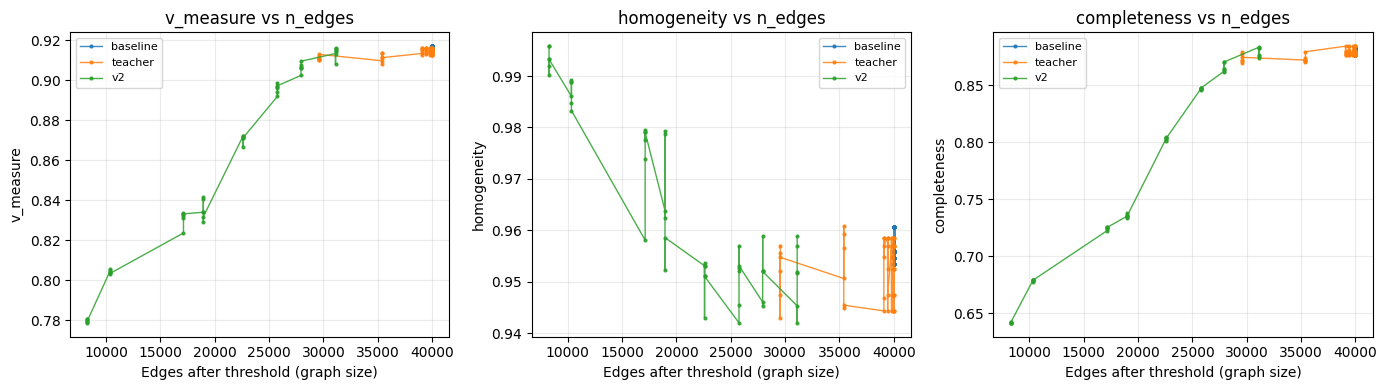

,method,target_n_edges,actual_n_edges,min_edge_weight,resolution,v_measure,homogeneity,completeness,n_communities
0,baseline,16000,40004.0,0.01,1.5,0.916969,0.953413,0.883209,860.0
1,baseline,21000,40004.0,0.01,1.5,0.916969,0.953413,0.883209,860.0
2,baseline,27000,40004.0,0.01,1.5,0.916969,0.953413,0.883209,860.0
3,baseline,33000,40004.0,0.01,1.5,0.916969,0.953413,0.883209,860.0
4,baseline,40000,40004.0,0.01,1.5,0.916969,0.953413,0.883209,860.0
5,teacher,16000,29551.0,0.30,3.5,0.912232,0.957030,0.871441,1007.0
6,teacher,21000,29551.0,0.30,3.5,0.912232,0.957030,0.871441,1007.0
7,teacher,27000,29551.0,0.30,3.5,0.912232,0.957030,0.871441,1007.0
8,teacher,33000,35401.0,0.20,1.5,0.911320,0.945415,0.879597,840.0
9,teacher,40000,40002.0,0.01,1.5,0.913452,0.944314,0.884544,826.0


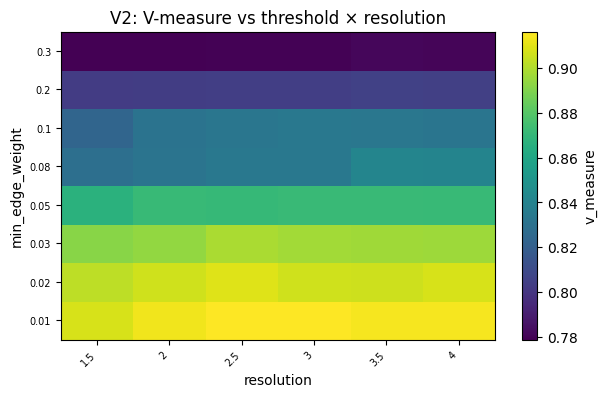

In [7]:
sweep_baseline = run_step3_sweep_df(
    assignments_df=assignments_df,
    shard_ids=shard_ids,
    edges_df=edges_df,
    gt_label_map=gt_label_map,
    method=COMMUNITY_METHOD,
    resolution_values=RESOLUTION_VALUES,
    min_edge_weight_values=MIN_EDGE_WEIGHT_VALUES,
    weight_col="edge_weight",
    seed=STEP3_SEED,
)
sweep_teacher = run_step3_sweep_df(
    assignments_df=assignments_df,
    shard_ids=shard_ids,
    edges_df=teacher_scored,
    gt_label_map=gt_label_map,
    method=COMMUNITY_METHOD,
    resolution_values=RESOLUTION_VALUES,
    min_edge_weight_values=MIN_EDGE_WEIGHT_VALUES,
    weight_col=TEACHER_WEIGHT_COL,
    seed=STEP3_SEED,
)
sweep_v2 = run_step3_sweep_df(
    assignments_df=assignments_df,
    shard_ids=shard_ids,
    edges_df=v2_scored,
    gt_label_map=gt_label_map,
    method=COMMUNITY_METHOD,
    resolution_values=RESOLUTION_VALUES,
    min_edge_weight_values=MIN_EDGE_WEIGHT_VALUES,
    weight_col="edge_plausibility",
    seed=STEP3_SEED,
)

fair = fair_method_comparison_table(
    baseline_sweep=sweep_baseline,
    teacher_sweep=sweep_teacher,
    v2_sweep=sweep_v2,
)
display(fair)
fair.to_csv(DIAG_OUT / "fair_method_comparison.csv", index=False)

for name, sdf in [
    ("baseline", sweep_baseline),
    ("teacher", sweep_teacher),
    ("v2", sweep_v2),
]:
    display(name, top_n_sweep_results(sdf, n=15))

long_sw = sweep_long_for_plotting(
    {"baseline": sweep_baseline, "teacher": sweep_teacher, "v2": sweep_v2}
)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["v_measure", "homogeneity", "completeness"]):
    plot_metrics_vs_n_edges(long_sw, metric=metric, title=f"{metric} vs n_edges", ax=ax)
plt.tight_layout()
plt.show()

matched = matched_edge_count_table(
    {"baseline": sweep_baseline, "teacher": sweep_teacher, "v2": sweep_v2},
    target_edge_counts=[16_000, 21_000, 27_000, 33_000, 40_000],
)
display(matched)
matched.to_csv(DIAG_OUT / "matched_edge_count_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
plot_sweep_heatmap(sweep_v2, title="V2: V-measure vs threshold × resolution", ax=ax)
plt.show()

## 8. Per-epoch checkpoint evaluation

Train V2 with `EdgePlausibilityV2Config(save_every_epoch_checkpoint=True)` so each epoch writes `checkpoints/epoch_XXXX.pt`. Then this cell scores every checkpoint and runs the same Step 3 grid.

,epoch,checkpoint,best_v_measure,best_homogeneity,best_completeness,min_edge_weight_at_best,resolution_at_best,n_edges_at_best,score_mean,score_std,score_q10,score_q90,pearson_vs_teacher,spearman_vs_teacher,pearson_vs_baseline_weight,spearman_vs_baseline_weight
0,1,C:\Users\aar\Desktop\GNN-Campaign-Detection\an...,0.916042,0.958547,0.877147,0.30,3.5,24403.0,0.370348,0.169833,0.145792,0.592751,0.527314,0.521446,0.832834,0.850212
1,2,C:\Users\aar\Desktop\GNN-Campaign-Detection\an...,0.930088,0.978724,0.886057,0.08,3.0,23555.0,0.166334,0.164636,0.019145,0.420025,0.614560,0.626625,0.700585,0.845650
2,3,C:\Users\aar\Desktop\GNN-Campaign-Detection\an...,0.930142,0.978008,0.886742,0.10,3.5,18475.0,0.150453,0.174510,0.009624,0.412575,0.619680,0.656405,0.648487,0.832320
3,4,C:\Users\aar\Desktop\GNN-Campaign-Detection\an...,0.926640,0.971795,0.885496,0.10,3.5,18711.0,0.159710,0.191836,0.008970,0.458666,0.620856,0.675807,0.626479,0.822475
4,5,C:\Users\aar\Desktop\GNN-Campaign-Detection\an...,0.930099,0.978838,0.885983,0.10,3.0,16918.0,0.149503,0.195948,0.005138,0.458360,0.598232,0.672340,0.600672,0.800490
5,6,C:\Users\aar\Desktop\GNN-Campaign-Detection\an...,0.918374,0.960492,0.879795,0.03,4.0,26766.0,0.153257,0.202667,0.004183,0.479358,0.588547,0.668821,0.592149,0.804513
6,7,C:\Users\aar\Desktop\GNN-Campaign-Detection\an...,0.927006,0.972247,0.885789,0.10,4.0,16821.0,0.141118,0.190416,0.002618,0.424795,0.586455,0.668376,0.556184,0.766719
7,8,C:\Users\aar\Desktop\GNN-Campaign-Detection\an...,0.920906,0.971093,0.875651,0.10,3.5,17103.0,0.153328,0.212386,0.001937,0.498480,0.577682,0.665546,0.583306,0.793430
8,9,C:\Users\aar\Desktop\GNN-Campaign-Detection\an...,0.924841,0.971937,0.882098,0.10,3.5,17312.0,0.160182,0.220730,0.002005,0.536035,0.595053,0.683578,0.599148,0.797637
9,10,C:\Users\aar\Desktop\GNN-Campaign-Detection\an...,0.925580,0.972939,0.882618,0.10,3.5,16805.0,0.150604,0.213644,0.001380,0.502780,0.589120,0.684850,0.570182,0.772796


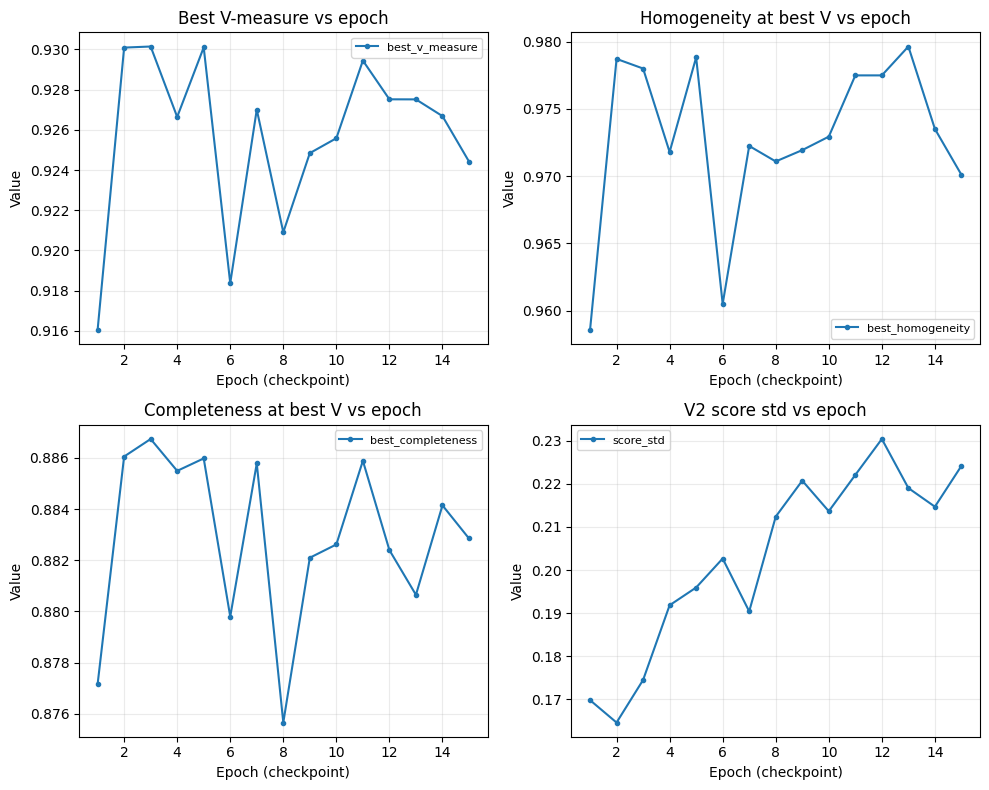

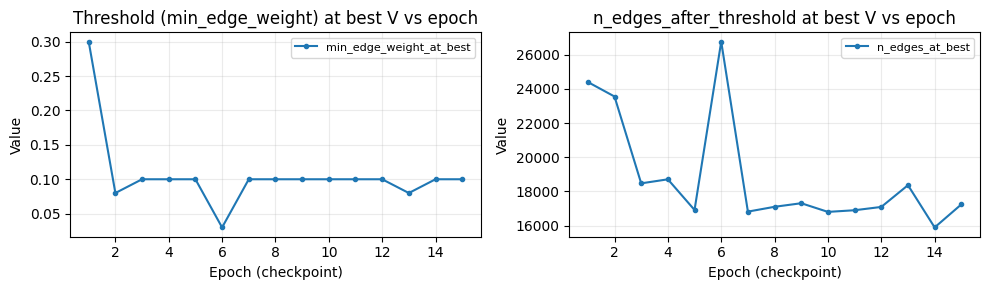

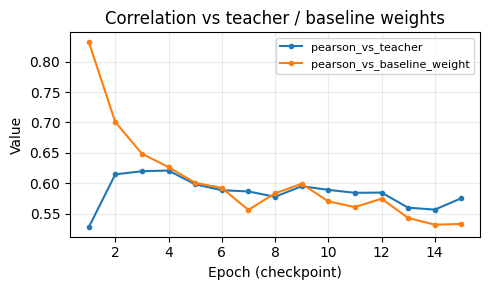

In [7]:
epoch_df = evaluate_v2_checkpoint_epochs(
    baseline_edges=edges_df,
    nodes_df=nodes_df,
    v2_run_dir=V2_RUN_DIR,
    assignments_df=assignments_df,
    shard_ids=shard_ids,
    gt_label_map=gt_label_map,
    method=COMMUNITY_METHOD,
    resolution_values=RESOLUTION_VALUES,
    min_edge_weight_values=MIN_EDGE_WEIGHT_VALUES,
    seed=STEP3_SEED,
    device="cpu",
    epochs_filter=EPOCH_CHECKPOINT_FILTER,
    gt_score_separation_assignments_df=assignments_df,
    gt_score_separation_label_map=gt_label_map,
)
display(epoch_df)
if not epoch_df.empty:
    epoch_df.to_csv(DIAG_OUT / "per_epoch_checkpoint_summary.csv", index=False)
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    plot_epoch_curves(epoch_df, ycols=["best_v_measure"], title="Best V-measure vs epoch", ax=axes[0, 0])
    plot_epoch_curves(epoch_df, ycols=["best_homogeneity"], title="Homogeneity at best V vs epoch", ax=axes[0, 1])
    plot_epoch_curves(epoch_df, ycols=["best_completeness"], title="Completeness at best V vs epoch", ax=axes[1, 0])
    plot_epoch_curves(epoch_df, ycols=["score_std"], title="V2 score std vs epoch", ax=axes[1, 1])
    plt.tight_layout()
    plt.show()
    fig_sp, axes_sp = plt.subplots(1, 2, figsize=(10, 3))
    plot_epoch_curves(
        epoch_df,
        ycols=["min_edge_weight_at_best"],
        title="Threshold (min_edge_weight) at best V vs epoch",
        ax=axes_sp[0],
    )
    plot_epoch_curves(
        epoch_df,
        ycols=["n_edges_at_best"],
        title="n_edges_after_threshold at best V vs epoch",
        ax=axes_sp[1],
    )
    plt.tight_layout()
    plt.show()
    fig2, ax2 = plt.subplots(figsize=(5, 3))
    plot_epoch_curves(
        epoch_df,
        ycols=["pearson_vs_teacher", "pearson_vs_baseline_weight"],
        title="Correlation vs teacher / baseline weights",
        ax=ax2,
    )
    plt.tight_layout()
    plt.show()
    if "gt_mean_gap_same_minus_cross" in epoch_df.columns:
        fig_gap, ax_gap = plt.subplots(figsize=(7, 3))
        plot_separation_gaps_vs_epoch(epoch_df, ax=ax_gap, title="Step-3 sweep checkpoints: GT separation gap vs epoch")
        plt.tight_layout()
        plt.show()
else:
    print("No epoch checkpoints found. Enable save_every_epoch_checkpoint in training.")

## 8b. Same vs cross score distributions across checkpoints

Scores every `epoch_XXXX.pt` on **all** baseline edges (no Step 3) and summarizes **same-campaign** vs **cross-campaign** plausibility under the GT taxonomy, plus the **HS-LI** view subset. Use the mean lines and p25–p75 bands to see whether cross scores fall and same scores rise over training; the histogram row compares early / mid / late checkpoints on the same axes scale.

In [ ]:
from IPython.display import display

_score_stats = evaluate_v2_checkpoint_same_cross_score_stats(
    baseline_edges=edges_df,
    nodes_df=nodes_df,
    v2_run_dir=V2_RUN_DIR,
    assignments_df=assignments_df,
    gt_label_map=gt_label_map,
    device="cpu",
    epochs_filter=EPOCH_CHECKPOINT_FILTER,
)
if _score_stats.empty:
    print("No epoch checkpoints for same/cross stats (enable save_every_epoch_checkpoint).")
else:
    display(_score_stats)
    _score_stats.to_csv(DIAG_OUT / "per_epoch_same_cross_score_stats.csv", index=False)

    fig_sc, _ = plot_same_cross_score_evolution(_score_stats)
    plt.show()

    fig_gap2, ax_gap2 = plt.subplots(figsize=(7, 3))
    plot_separation_gaps_vs_epoch(
        _score_stats,
        ax=ax_gap2,
        title="Per-checkpoint table: mean(same) − mean(cross)",
    )
    plt.tight_layout()
    plt.show()

    _same_m, _cross_m, _hsli_m = v2_gt_same_cross_hsli_masks(
        edges_df, assignments_df, gt_label_map, V2_RUN_DIR
    )
    _epochs_snap = sorted(_score_stats["epoch"].astype(int).tolist())
    if len(_epochs_snap) > 3:
        _pick = [_epochs_snap[0], _epochs_snap[len(_epochs_snap) // 2], _epochs_snap[-1]]
    else:
        _pick = _epochs_snap
    _snaps = {}
    for _ep in _pick:
        _s = score_v2_at_epoch_checkpoint(edges_df, nodes_df, V2_RUN_DIR, int(_ep), device="cpu")
        _snaps[f"epoch {_ep}"] = (_s[_same_m], _s[_cross_m])
    fig_hist, _ = plot_same_cross_histogram_snapshots(_snaps)
    plt.show()

    _snaps_hsli = {}
    for _ep in _pick:
        _s = score_v2_at_epoch_checkpoint(edges_df, nodes_df, V2_RUN_DIR, int(_ep), device="cpu")
        _snaps_hsli[f"epoch {_ep} (HS-LI)"] = (_s[_same_m & _hsli_m], _s[_cross_m & _hsli_m])
    if any(a.size > 0 or b.size > 0 for a, b in _snaps_hsli.values()):
        fig_hist2, _ = plot_same_cross_histogram_snapshots(_snaps_hsli)
        plt.show()

## 9b. V2 ranking supervision (buckets / teacher fallback)

Uses `V2_RUN_DIR` artifacts: `training_history.json` (per-epoch `pair_batches_*`) and `ranking_supervision_meta.json` (bucket counts by split, backup subpaths). Writes compact CSV/JSON under `DIAG_OUT` for inspection and manual run-to-run comparison.

In [13]:
from IPython.display import display

_rs = save_v2_ranking_supervision_diagnostics_report(V2_RUN_DIR, output_dir=DIAG_OUT)
print("Written:", _rs["paths"])
_hist = load_v2_training_history(V2_RUN_DIR)
_meta = load_v2_ranking_supervision_meta(V2_RUN_DIR)
if not _hist.empty:
    _fe = v2_ranking_supervision_fallback_per_epoch_df(_hist)
    display_cols = [
        "epoch",
        "pair_batches_buckets",
        "pair_batches_fallback_teacher",
        "pair_batches_fallback_partial",
        "pair_batches_legacy_teacher",
        "n_pair_batches",
        "frac_batches_bucket",
        "frac_batches_any_teacher_fallback",
    ]
    _show = [c for c in display_cols if c in _fe.columns]
    display(_fe[_show])
    print("Run summary:", v2_ranking_supervision_fallback_run_summary(_hist))
else:
    print("No training_history.json in", V2_RUN_DIR)

_b = v2_bucket_counts_table_from_meta(_meta)
_p = v2_positive_subpath_counts_table_from_meta(_meta)
if not _b.empty:
    display(_b)
if not _p.empty:
    display(_p)
print(v2_ranking_supervision_factual_note(_meta, v2_ranking_supervision_fallback_run_summary(_hist)))

Written: {'fallback_per_epoch_csv': 'C:\\Users\\aar\\Desktop\\GNN-Campaign-Detection\\analysis\\output\\semantic_shard_method2_diagnostics\\v2_notebook_30_epochs\\v2_ranking_supervision_fallback_per_epoch.csv', 'bucket_counts_csv': 'C:\\Users\\aar\\Desktop\\GNN-Campaign-Detection\\analysis\\output\\semantic_shard_method2_diagnostics\\v2_notebook_30_epochs\\v2_ranking_supervision_bucket_counts_by_split.csv', 'positive_subpath_csv': 'C:\\Users\\aar\\Desktop\\GNN-Campaign-Detection\\analysis\\output\\semantic_shard_method2_diagnostics\\v2_notebook_30_epochs\\v2_ranking_supervision_positive_subpath_counts_by_split.csv', 'report_json': 'C:\\Users\\aar\\Desktop\\GNN-Campaign-Detection\\analysis\\output\\semantic_shard_method2_diagnostics\\v2_notebook_30_epochs\\v2_ranking_supervision_report.json'}


,epoch,pair_batches_buckets,pair_batches_fallback_teacher,pair_batches_fallback_partial,pair_batches_legacy_teacher,n_pair_batches,frac_batches_bucket,frac_batches_any_teacher_fallback
0,0.0,71.0,0.0,0.0,0.0,71.0,1.0,0.0
1,1.0,71.0,0.0,0.0,0.0,71.0,1.0,0.0
2,2.0,71.0,0.0,0.0,0.0,71.0,1.0,0.0
3,3.0,71.0,0.0,0.0,0.0,71.0,1.0,0.0
4,4.0,71.0,0.0,0.0,0.0,71.0,1.0,0.0
5,5.0,71.0,0.0,0.0,0.0,71.0,1.0,0.0
6,6.0,71.0,0.0,0.0,0.0,71.0,1.0,0.0
7,7.0,71.0,0.0,0.0,0.0,71.0,1.0,0.0
8,8.0,71.0,0.0,0.0,0.0,71.0,1.0,0.0
9,9.0,71.0,0.0,0.0,0.0,71.0,1.0,0.0


Run summary: {'n_epochs': 40, 'total_bucket_batches': 2840, 'total_fallback_teacher_batches': 0, 'total_fallback_partial_batches': 0, 'total_legacy_teacher_batches': 0, 'total_pair_batches': 2840, 'frac_all_batches_bucket': 1.0, 'frac_all_batches_any_teacher_fallback': 0.0}


,split,strong_pos,hard_neg,strong_neg,unassigned,n_edges_in_split
0,full,6624,4161,6021,23198,40004
1,train,5941,3759,5403,20901,36004
2,val,683,402,618,2297,4000


,split,robust_core_in_strong_pos,rarity_only_in_strong_pos,backup_teacher_only_in_strong_pos,backup_teacher_predicate_n,backup_teacher_in_strong_pos_n
0,full,1869,2994,1761,5233,5233
1,train,1672,2691,1578,4701,4701
2,val,197,303,183,532,532


- **Fallback usage:** Teacher-style fallback batches are **rare** overall (`frac_any_teacher_fallback` ≈ 0.0000 over all train pair-batches).
- **Bucket-driven batches:** ≈ 1.0000 of all train pair-batches used pure bucket sampling.
- **Train split buckets:** n_edges=36004; min(strong_pos, strong_neg, hard_neg)=3759. Very small pools increase hybrid fallback risk.
- **Val split buckets:** n_edges=4000; min(strong_pos, strong_neg, hard_neg)=402.
- **backup_teacher path:** 5233 edges satisfy the backup predicate on the full graph; 1761 **strong_pos** are *only* via backup (not robust_core / rarity disjunct). As a share of all strong_pos: backup-only ≈ 0.2659.


## 10. Training history and final-run GT separation artifacts

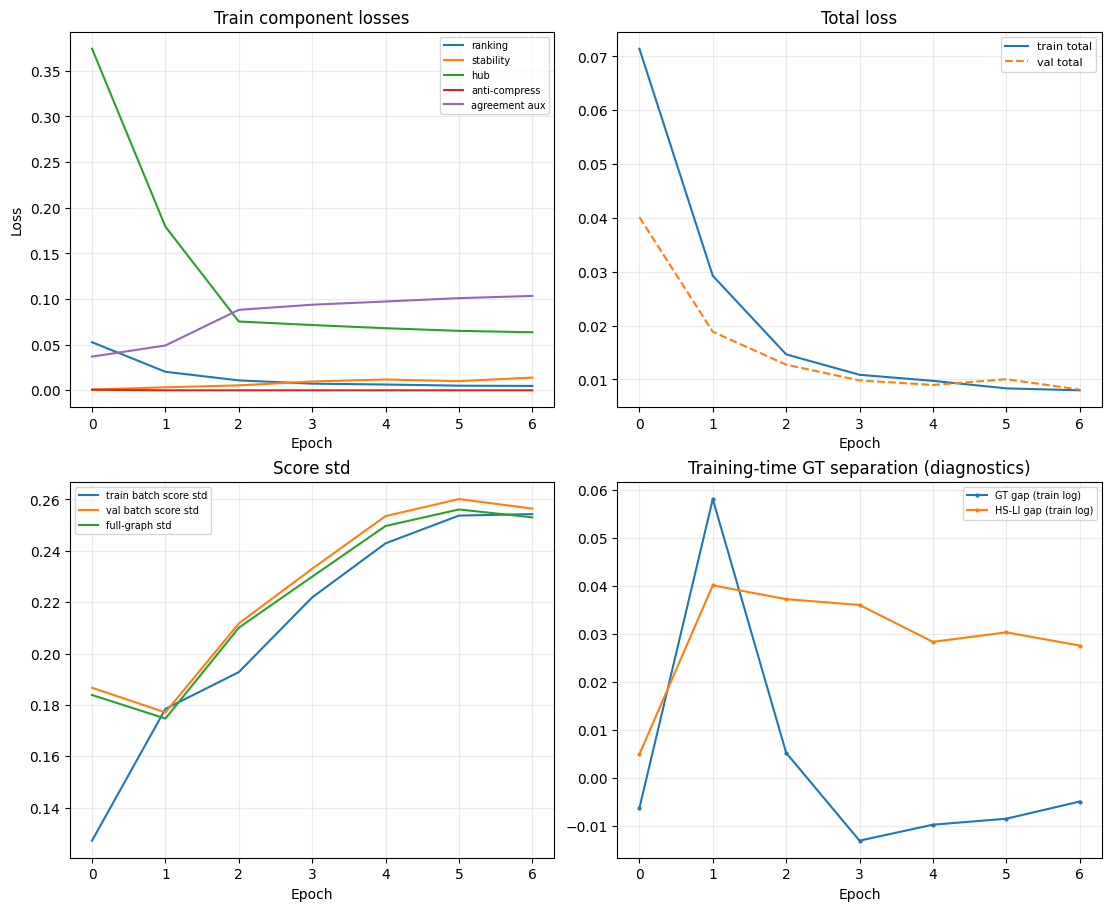

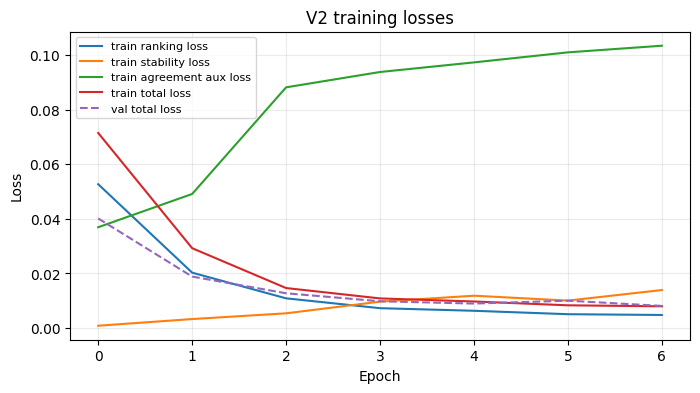

--- v2_gt_score_separation.json ---
{
  "same": {
    "n": 1322,
    "mean": 0.1008567050516425,
    "median": 0.06139218620955944,
    "p10": 0.024651632271707056,
    "p25": 0.03816923592239618,
    "p50": 0.06139218620955944,
    "p75": 0.12847191467881203,
    "p90": 0.1909822851419449
  },
  "cross": {
    "n": 541,
    "mean": 0.10578731191199309,
    "median": 0.09161092340946198,
    "p10": 0.010755092836916447,
    "p25": 0.03568276762962341,
    "p50": 0.09161092340946198,
    "p75": 0.14486263692378998,
    "p90": 0.19239693880081177
  },
  "mean_gap_same_minus_cross": -0.0049306068603505865,
  "median_gap_same_minus_cross": -0.030218737199902534,
  "threshold_table": [
    {
      "threshold": 0.01447,
      "frac_same_above": 0.9765506807866868,
      "frac_cross_above": 0.8835489833641405
    },
    {
      "threshold": 0.02,
      "frac_same_above": 0.9440242057488654,
      "frac_cross_above": 0.8428835489833642
    },
    {
      "threshold": 0.021567,
      "frac_same

In [6]:
# Reload so edits to diagnostics_plots.py apply without restarting the kernel
import importlib
import json
from pathlib import Path

import analysis.utils.semantic_shard_method2_v2_diagnostics_plots as _m2plots
importlib.reload(_m2plots)

hist = load_v2_training_history(V2_RUN_DIR)
if hist.empty:
    print("No training_history.json")
else:
    fig_m, _ = _m2plots.plot_training_history_multipanel(hist)
    plt.show()
    fig_l, ax_l = plt.subplots(figsize=(8, 4))
    _m2plots.plot_training_history_losses(hist, ax=ax_l)
    plt.show()

_run = Path(V2_RUN_DIR)
for _name in (
    "v2_gt_score_separation.json",
    "v2_gt_score_separation_thresholds.csv",
    "v2_gt_score_separation_hsli_thresholds.csv",
):
    _p = _run / _name
    if not _p.is_file():
        continue
    print("---", _p.name, "---")
    if _p.suffix == ".json":
        print(json.dumps(json.loads(_p.read_text(encoding="utf-8")), indent=2)[:8000])
    else:
        print(pd.read_csv(_p).head(50).to_string())